In [456]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 
from sympy import *

## Inspiration

The aim of this notebook is to use computation on both analytical and numerical solutions of a cross section of an infinitly long cylinder. The cylinder is hot on one side and cold on the other. Both solutions are for steady state heat distribution, there is no warming or cooling involved, the cylinder has been under these conditions for a while and the temprature inside it has normalised.


As I have been doing this project, a couple of situations have come to mind where this simulation may be applicable. 
A Tuscan column is heated on one side after the sun has risen, the other side being in the shade, backs onto a building. 
A solid metal pole on a satelite is heated on one side by the sun, the other side faces out into space. 


The analytical approch offers a more mathmatical solution to Laplace's heat equation in polar coordinates. Whereas the numerical solution by iteration, offers a much more intuitive approach to how the steady state heat distribution may look. The numerical solution is how I imagine it in my head as the temprature depends on the immediate points around it. I wanted with this notebook to compare the two and see how they differ. 

## Analytical solution 

In [ ]:

radius = 2 
D = 100

a = radius
# I need to find out how polar plots in matplotlib takes information and 
u = 1   # temprature differential

 
def simulation(N):  # pick an n value for the Fourier series
    
    r = np.linspace(0, radius , D) # this gives me each 50 possible values r can take       
    theta = np.linspace(-np.pi, np.pi , D) # this sets my discretisation for theta  from - pi to pi 
                                                                                                    
    U = np.zeros((len(theta), len(r))) # empty array for storage of values 
    n = np.arange(1,N+1)  # an array for n has to be 1, N + 1 to avoid multipling with index 0, but keeping the same length n 
    
    

    for i in range (len(n)):
        for j in range(len(theta)):
            U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )  
    return U
    # += needed to sum the fourier terms 
#drops all values of r for a particular theta into the x column as u[:,j] selects the whole column puts all the r values in, then moves on to the next value of theta
# the colums contain all values of r for a particular value of theta 

#simulation(10)

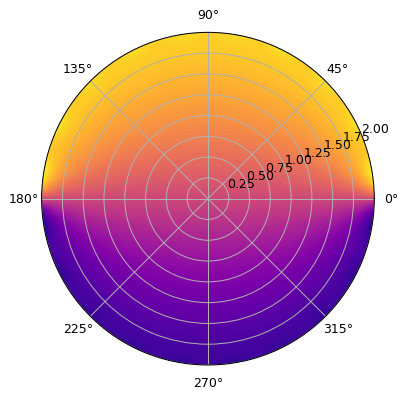

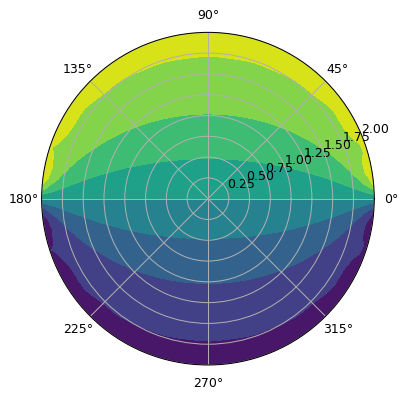

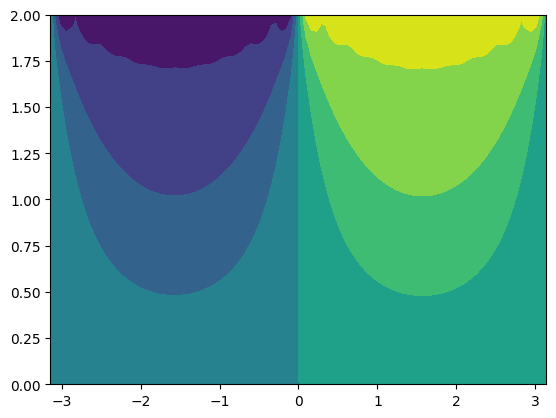

array([-1.02365228e-16, -5.28158787e-02, -1.04707169e-01, -1.54833579e-01,
       -2.02504923e-01, -2.47216943e-01, -2.88655865e-01, -3.26678719e-01,
       -3.61280052e-01, -3.92554759e-01, -4.20663559e-01, -4.45804459e-01,
       -4.68191179e-01, -4.88038084e-01, -5.05550411e-01, -5.20918379e-01,
       -5.34314001e-01, -5.45889751e-01, -5.55778457e-01, -5.64093883e-01,
       -5.70931604e-01, -5.76369928e-01, -5.80470831e-01, -5.83280832e-01,
       -5.84831718e-01, -5.85141021e-01, -5.84212238e-01, -5.82034869e-01,
       -5.78584297e-01, -5.73821445e-01, -5.67692169e-01, -5.60126441e-01,
       -5.51037437e-01, -5.40320603e-01, -5.27852740e-01, -5.13491239e-01,
       -4.97073781e-01, -4.78418983e-01, -4.57328572e-01, -4.33591801e-01,
       -4.06993109e-01, -3.77324364e-01, -3.44403068e-01, -3.08097428e-01,
       -2.68358130e-01, -2.25254786e-01, -1.79012204e-01, -1.30038219e-01,
       -7.89324911e-02, -2.64667635e-02,  2.64667635e-02,  7.89324911e-02,
        1.30038219e-01,  

In [486]:

zs = simulation(10)


r = np.linspace(0, radius , D) 
theta = np.linspace(-np.pi, np.pi , D)  #-np.pi, np.pi
#h = plt.contourf(theta, r, zs)
#plt.colorbar()
#plt.show()
plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )  # matplotlib constructing a plot where it takes polar arguments, converts them to cartesian and plots them 
#nicely on the interface, it takes the first value of r and the first theta for all values for theta then does the second r, which is why this works for my r by theta array U.
plt.contourf(theta , r, zs, 100, cmap = 'plasma') 
plt.show()

plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )   
plt.contourf(theta , r, zs)
plt.show()

plt.contourf(theta,r ,zs)
plt.show()

zs[49, :]

## Euclidean norm & fourier visualisation

In [488]:

#[49,:] is the last circle of theta at max r 
zs[D -1 ,:].round(2) # and zs[49,]

array([-0.  , -0.74, -1.14, -1.14, -0.98, -0.9 , -0.97, -1.06, -1.05,
       -0.98, -0.95, -0.99, -1.04, -1.03, -0.98, -0.96, -0.99, -1.03,
       -1.02, -0.98, -0.97, -1.  , -1.03, -1.02, -0.98, -0.97, -1.  ,
       -1.03, -1.02, -0.98, -0.97, -1.  , -1.03, -1.02, -0.97, -0.96,
       -1.01, -1.04, -1.02, -0.96, -0.95, -1.02, -1.07, -1.02, -0.92,
       -0.92, -1.06, -1.18, -0.99, -0.4 ,  0.4 ,  0.99,  1.18,  1.06,
        0.92,  0.92,  1.02,  1.07,  1.02,  0.95,  0.96,  1.02,  1.04,
        1.01,  0.96,  0.97,  1.02,  1.03,  1.  ,  0.97,  0.98,  1.02,
        1.03,  1.  ,  0.97,  0.98,  1.02,  1.03,  1.  ,  0.97,  0.98,
        1.02,  1.03,  0.99,  0.96,  0.98,  1.03,  1.04,  0.99,  0.95,
        0.98,  1.05,  1.06,  0.97,  0.9 ,  0.98,  1.14,  1.14,  0.74,
        0.  ])

In [461]:
# therefore were looking at boundary conditions of 

#zs[0,0:24] = -100 # for the 
#zs[0,24:49] = 100
periscope = zs.round(2)


np.set_printoptions(threshold=np.inf)
#periscope

In [462]:
periscope[49,:] # it looks like the top side is actually the cold side (if python truly is going anticlockwise)
# this is the rim of the cicle NOTICE!!! that the value of U jumps up and then down and then up and then down. This is because of the fourier approximation not being perfect.
# with a hight value of n this would likely be much less obvious very cool!!!!
#before saying that in the final thing make sure thats right

array([-0.  , -0.05, -0.1 , -0.15, -0.2 , -0.25, -0.29, -0.33, -0.36,
       -0.39, -0.42, -0.45, -0.47, -0.49, -0.51, -0.52, -0.53, -0.55,
       -0.56, -0.56, -0.57, -0.58, -0.58, -0.58, -0.58, -0.59, -0.58,
       -0.58, -0.58, -0.57, -0.57, -0.56, -0.55, -0.54, -0.53, -0.51,
       -0.5 , -0.48, -0.46, -0.43, -0.41, -0.38, -0.34, -0.31, -0.27,
       -0.23, -0.18, -0.13, -0.08, -0.03,  0.03,  0.08,  0.13,  0.18,
        0.23,  0.27,  0.31,  0.34,  0.38,  0.41,  0.43,  0.46,  0.48,
        0.5 ,  0.51,  0.53,  0.54,  0.55,  0.56,  0.57,  0.57,  0.58,
        0.58,  0.58,  0.59,  0.58,  0.58,  0.58,  0.58,  0.57,  0.56,
        0.56,  0.55,  0.53,  0.52,  0.51,  0.49,  0.47,  0.45,  0.42,
        0.39,  0.36,  0.33,  0.29,  0.25,  0.2 ,  0.15,  0.1 ,  0.05,
        0.  ])

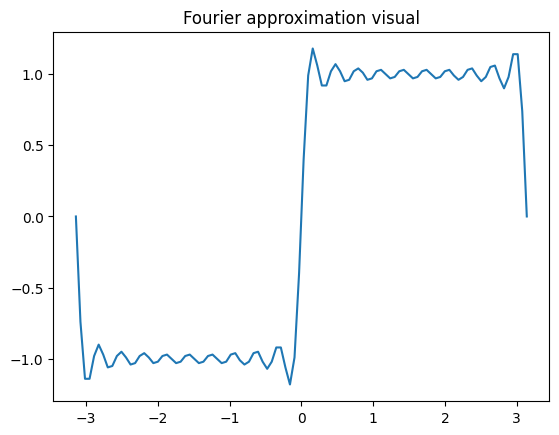

[-0.   -0.74 -1.14 -1.14 -0.98 -0.9  -0.97 -1.06 -1.05 -0.98 -0.95 -0.99
 -1.04 -1.03 -0.98 -0.96 -0.99 -1.03 -1.02 -0.98 -0.97 -1.   -1.03 -1.02
 -0.98 -0.97 -1.   -1.03 -1.02 -0.98 -0.97 -1.   -1.03 -1.02 -0.97 -0.96
 -1.01 -1.04 -1.02 -0.96 -0.95 -1.02 -1.07 -1.02 -0.92 -0.92 -1.06 -1.18
 -0.99 -0.4   0.4   0.99  1.18  1.06  0.92  0.92  1.02  1.07  1.02  0.95
  0.96  1.02  1.04  1.01  0.96  0.97  1.02  1.03  1.    0.97  0.98  1.02
  1.03  1.    0.97  0.98  1.02  1.03  1.    0.97  0.98  1.02  1.03  0.99
  0.96  0.98  1.03  1.04  0.99  0.95  0.98  1.05  1.06  0.97  0.9   0.98
  1.14  1.14  0.74  0.  ]


In [463]:
thetaplots = np.linspace(-np.pi, np.pi, D)
#y = np.linspace(0, 50, )
plotable =  periscope[D-1,:] # detaching slice from the D by D array 
#plt.show()

plotable.shape
plt.plot(thetaplots, plotable)
plt.title('Fourier approximation visual')
plt.show()
print(plotable)

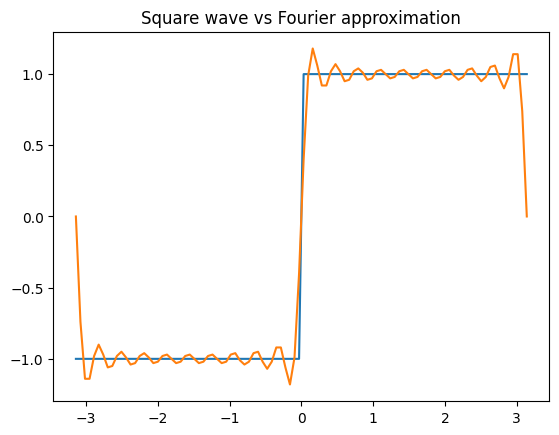

1.0622617379911603


In [ ]:
# Creating the square wave
ftheta = np.linspace(-np.pi, np.pi, D)
for i in range(D):
   if -np.pi <= ftheta[i] <= 0 :
            ftheta[i] = -1
   elif 0 <= ftheta[i] <= np.pi:
      ftheta[i] = 1

# Plotting the square wave vs the last value of r, with Euclidean norm.
thetaplots = np.linspace(-np.pi, np.pi, D)
plt.plot(thetaplots, ftheta)
plt.plot(thetaplots, plotable)
plt.title('Square wave vs Fourier approximation')
plt.show()

norm = np.linalg.norm(plotable[1:len(plotable)-1] - ftheta[1 : len(ftheta)-1] )   # have to exclude the boundary values as they massively add to the euclidean norm
print(norm)            
    

In [465]:
print(ftheta)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


In [466]:
N_list = [ 4,8,12,16,20,24,28,32, 34]         # reduced due to overflow on higher values 

norms = np.zeros(len(N_list))

for i in range(len(N_list)):                                 # The euclidean norm here is all wrong the values are much too high 
    A = simulation(N_list[i])
    slice = A[D-1, :]

    norms[i] = np.linalg.norm(slice[2: len(slice) -2 ] - ftheta[2: len(ftheta)-2])  # excluding thoes outer values for a decent euclidean norm 

print(norms)

[1.76504927 1.14421167 0.8887628  0.68429133 0.48636201 0.31594022
 0.21685503 0.28248795        nan]


C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: divide by zero encountered in divide
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: invalid value encountered in divide
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\3728005781.py:25: RuntimeWarning: invalid value encountered in add
  U[:, j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )


eqn destabilises at around n = 30, but shows good convergence until then. 

<function matplotlib.pyplot.show(close=None, block=None)>

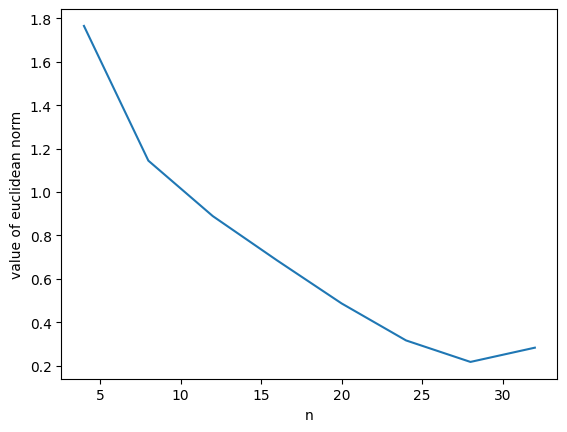

In [ ]:
plt.plot(N_list, norms)
plt.xlabel('n')
plt.ylabel('value of euclidean norm')
plt.show

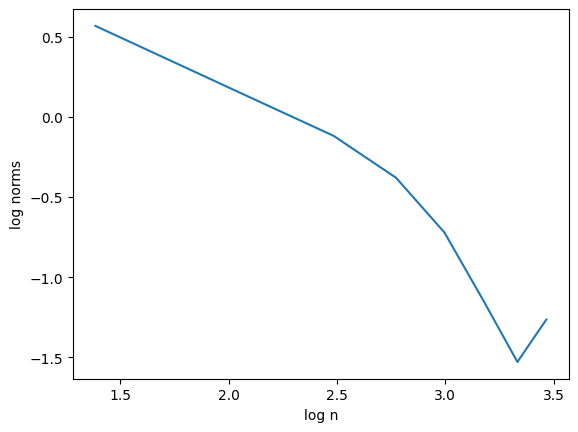

In [468]:
plt.plot(np.log(N_list), np.log(norms))
plt.xlabel('log n')
plt.ylabel('log norms')
plt.show()

## Analytical solution assumptions and limitations

Assumptions   <br>
The model assumes that the heat on one side and the cold on the other are directly equal in magnitude. <br>
The model assumes that there are no external forces that could impact the steady state heat distribution <br>
The model assumes that the cylinder is infintely long in the z direction, requiring no z component. It also requires that the whole length of the infinitely long cylinder is heated on one side and cooled on another.   <br>
The model assumes that there is no heat transfered across the boundary, that the temprature at r = 0 is single valued and finite. <br>
<br>
Limitations  <br>
The fourier approximation breaks down at around n = 30, this is most likely because of the way I have constructed the formula in python, it means that the model does not offer a better approximation of the square wave function. However, if done properly with the same analytical solution, it should provide this.  <br>
At the lower values of n the model fails to provide an accurate approximation of the square wave. This is due to the gibbs phenonoma, where a Fourier approximation cannot accurately approximate sharp changes in directions of the function being approximatied. In this case the sharp changes in y at theta = 0 and at pi and -pi, lead the cosine terms to overshoot, this contributes to a higher euclidean norm. <br>
The model cannot provide accurate solutions to situations where the temprature on one side is not equal in magnitude to the temprature on the other side. <br>




## Numerical solution 

### Without the 1/r and 1/r^2 terms (Incorrect for polar)

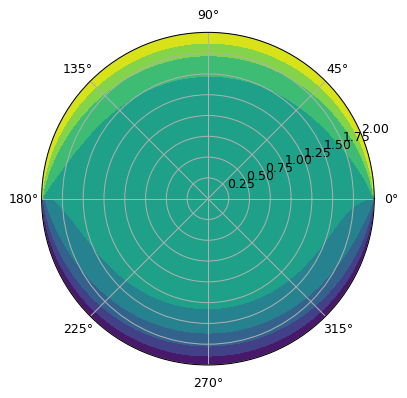

In [ ]:
max_iters = 500 # controls the number of iterations python does 

length_r = 100   # controls the number of circles of the r discretisation
length_theta = 100  # controls the number of wedges of the theta discretisation

radius = 2


the_top_temp = 100
the_bot_temp = -100
r_zero = 0

filler_value = 10


#r, theta = np.meshgrid(np.arange(0, length_r), np.arange(0,length_theta))  

r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 

#r, theta = np.meshgrid(np.linspace(0, radius , length_r), np.linspace(-np.pi, np.pi , length_theta) )


u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, (length_r//2): length_r] = the_top_temp         # issue with / returning a floating point, not an integer, for indexing integers are required
u[length_r-1, 0: (length_r//2)] = the_bot_temp             # this is done as python places polar arrays counter clockwise 
u[0, :] = r_zero


for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them. 
        for j in range(length_theta-1): #(1, (length_theta -1)):
            u[i,j] = 0.25* (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1])   # this is the formular for the cartesian not polar h here is 1 so h^2 = 1 hence stuff/1 = stuff



#plt.contourf(theta,r , u)
#plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     # maybe the tightening side needs to be on the x axis  thats why this works 
plt.contourf(theta, r ,u)   
plt.show()


I used this as an intermediary step for the coding of the polar solution, as that is more complex. However I left it in as I thought that it was interesting seeing what the discretisation looks like when python treats the array as a regular cartesian grid. You can then compare the two solutions to visually see the effects of the weightings on each of the circles. This one being muted and not resembeling the analytical solution at all.

### With the 1/r and 1/r^2 terms (correct numerical solution)

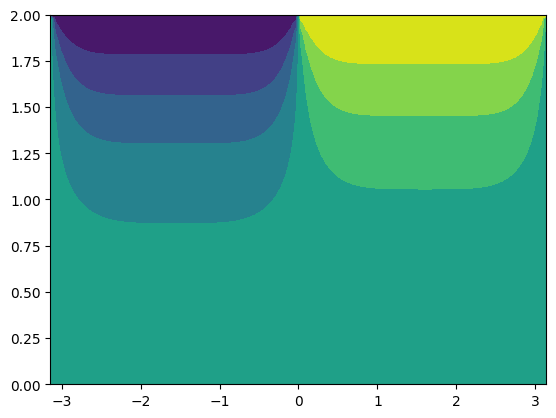

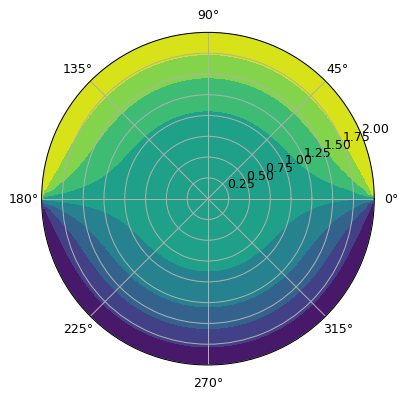

In [ ]:
max_iters = 500

length_r = 100
length_theta = 100

radius = 2



the_top_temp = 100         # Feel free to change these values 
the_bot_temp = -100
r_zero = 0

filler_value = 10



r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 



u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, 0: (length_r//2)] = the_bot_temp             # this is done as python places polar arrays counter clockwise 
u[length_r-1, (length_r//2): length_r] = the_top_temp         
#u[0, :] = r_zero       ~ This boundary condition is not needed for an accurate apporximation.



for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them.
        
        X = (r[i] - r[i-1])**2  # delta radius(i) squared                 # CHANGE IN R is just r2 -r1
        Y = (r[i] * (2*(r[i] - r[i-1])))          # radius(i) times 2 times delta r     
    

        for j in range(1, length_theta-1): 

            Z = ((r[i])**2 )*((theta[j] - theta[j-1])**2)  
            multiplier = ((r[i] - r[i-1])**2)* ((r[i])**2) * ((theta[j] - theta[j-1])**2) / ( (2*(((r[i])**2) * (theta[j] - theta[j-1])**2)) + 2*((r[i] - r[i -1])**2) )

            u[i,j] =  (multiplier) *( (u[i-1,j]/ X) + (u[i+1,j]/ X) + (u[i+1,j]/ Y) + (-u[i-1,j]/ Y) + (u[i,j-1]/ Z) + (u[i,j+1]/ Z) ) 




plt.contourf(theta,r , u)
plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     
plt.contourf(theta, r ,u)   
plt.show()

# python has to run the for loops many times, so computation may take a while.


## Numerical solution assumptions and limitations

Assumptions  <br>
The model assumes that heat transfer can be modelled by a finite difference approximation <br>
The model assumes that the boundary conditions are forever constant, they are excluded from the iteration, but inform on other points within the discretisation.  <br>
The model assumes that the weightings of the values within the laplacian accuractly describe the cross section of the cylinder heated on one side cooled on another.  <br>
<br>
Limitations <br>
The model is limited by not having variation, it cannot accound for if the temprature were to change with time. it is only for steady state heat distribution. <br>







## Comparison of the Two models
Looking at the two models you can see how their solutions differ. The analytical solution offers a more consistant cooling as the r tends to 0, whereas the numerical solution cools rapidly, the immediate area around r = 0 you can see is cooler. It is hard to tell which one is more accurate without comparing with a real life example, given that the heat on a cross section of an infinitely long cylinder will be difficult to measure, the two models are both worthwile exercises.<br>
The analytical solution provides a good model that is mathematically accurate. However, it only can offer a solution for the finite value where r = 0 you cannot vary the heat sources without returning to the general solution, this makes it less adaptable. <br>
This is evident when compared witht the numerical solution which can operate accross this boundary, you can vary the heat sources by array slicing or ajusting the bottom and top tempratures already set. <br>
In my opinion this makes the numerical more intuitave and pliable than the analytical solution, for this level of programming. 


## Credits / Bibliography 

Cauchy Euler eqn 

[https://math.libretexts.org/Bookshelves/Differential_Equations/A_First_Course_in_Differential_Equations_for_Scientists_and_Engineers_(Herman)/02%3A_Second_Order_ODEs/2.05%3A_Cauchy-Euler_Equations](https://math.libretexts.org/Bookshelves/Differential_Equations/A_First_Course_in_Differential_Equations_for_Scientists_and_Engineers_(Herman)/02%3A_Second_Order_ODEs/2.05%3A_Cauchy-Euler_Equations)

save of extra time request 

https://forms.office.com/Pages/ResponseDetailPage.aspx?id=sA0np77paEabo0fDROUm_6C3t-6ajhVEqHelJogsNBJUM1E4M01SVkhQOTg1UUVDTUhZQVA4RkU5WCQlQCN0PWcu&rid=241&GetResponseToken=LvfhdvTvPB2vbbTTMdEwDhlF9_vEe6L1aQzmQRnVmRg&origin=rc&prevsubpage=rcfre&d1obforrc=1&rcsidebar=0

videos used :

https://www.youtube.com/watch?v=A4_FepFBjwk

https://www.youtube.com/watch?v=ijQaTAT3kOg

https://www.youtube.com/watch?v=wmCIrpLBFds

https://www.youtube.com/watch?v=714h9_5LPso

https://www.youtube.com/watch?v=bsjIIWmeqEI - Poissons on unit disk

main video used :

https://www.youtube.com/watch?v=Yybsq8qiK9I

pdf’s :

pdf for deriving polar laplacian format : https://www.math.ucdavis.edu/~saito/courses/21C.w11/polar-lap.pdf

page four for the 9 point numerical solution exemplar:

https://jmscm.smartsociety.org/volume2_issue3/paper5.pdf

coding resources :

np.printoptions 

https://stackoverflow.com/questions/1987694/how-do-i-print-the-full-numpy-array-without-truncation

integer division

[https://www.learndatasci.com/solutions/python-double-slash-operator-floor-division/#:~:text=In Python%2C we can perform,floor() function](https://www.learndatasci.com/solutions/python-double-slash-operator-floor-division/#:~:text=In%20Python%2C%20we%20can%20perform,floor()%20function).

youtube video for polar plots 

https://www.youtube.com/watch?v=DyPjsj6azY4

matplotlib documentation :

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.add_subplot.html#matplotlib.figure.Figure.add_subplot

https://matplotlib.org/stable/api/projections_api.html#module-matplotlib.projections

https://matplotlib.org/stable/api/projections/polar.html

np.linalg.norm

https://numpy.org/devdocs/reference/generated/numpy.linalg.norm.html

array splicing 

https://www.w3schools.com/python/numpy/numpy_array_shape.asp

textbooks :

(pages 336 for finite difference formulas)

https://ereader.perlego.com/1/book/3884485/336

Natural Sciences Tripos: 1B mathematical Methods II pages (36 -38) (3.2.1 , 3.10 - 3.18) copyright [S.J.Cowley@maths.cam.ac.uk](mailto:S.J.Cowley@maths.cam.ac.uk), Lent 2021

## AI declaration / Git Commits 

Claude sonnet model 4.6 was used in this notebook for the following purposes: <br> 
Expanding on python errors (Claude was instructed not to suggest any code improvements, just explain in words the meaning of errors.) <br>
To check understanding (Claude was asked yes or no only whether calculations in the analytical solution was correct, this was done to avoid progressing with structural errors) <br>

This notebook and its numerical and analytical solutions, were constructed by myself using the resources in the bibliography. <br>
See the contents of the git hub repositry with 'git commits' for each point of the construction of this notebook.  <br>
https://github.com/peterassessments/Individiual-Simulation